In [ ]:
import pandas as pd
import numpy as np
from tensorflow.keras.layers import Dense,Dropout
from tensorflow.keras.models import Sequential
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.callbacks import EarlyStopping
import tensorflow
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.optimizers import SGD

In [ ]:
df = pd.read_csv("diabetes.csv")

In [203]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72.0,35,169.5,33.6,0.627,50,1
1,1,85,66.0,29,102.5,26.6,0.351,31,0
2,8,183,64.0,32,169.5,23.3,0.672,32,1
3,1,89,66.0,23,94.0,28.1,0.167,21,0
4,0,137,40.0,35,168.0,43.1,2.288,33,1


In [204]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    float64
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    float64
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(4), int64(5)
memory usage: 54.1 KB


In [205]:
df.shape

(768, 9)

In [206]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.677083,72.389323,29.089844,141.753906,32.434635,0.471876,33.240885,0.348958
std,3.369578,30.464161,12.106039,8.890820,89.100847,6.880498,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,25.000000,102.500000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,28.000000,102.500000,32.050000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,169.500000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


<Axes: >

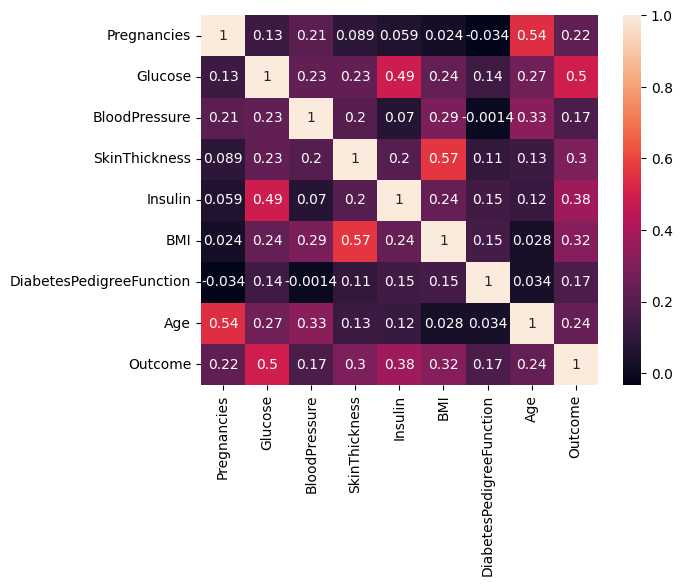

In [207]:
sns.heatmap(df.corr(), annot=True)

### Individual analysis

In [208]:
df["Pregnancies"].value_counts()

,count
Pregnancies,
1,135
0,111
2,103
3,75
4,68
5,57
6,50
7,45
8,38


<Axes: xlabel='Pregnancies'>

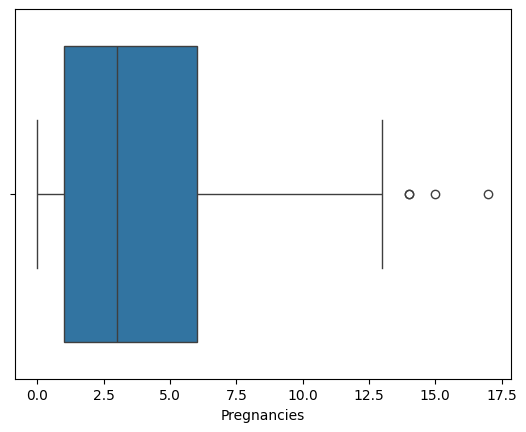

In [209]:
sns.boxplot(x="Pregnancies" , data=df)

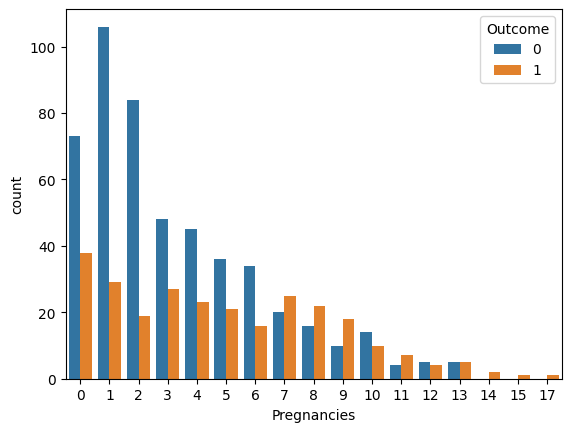

In [210]:
sns.countplot(x="Pregnancies", hue="Outcome", data=df)
plt.show()

<Axes: xlabel='Glucose', ylabel='Density'>

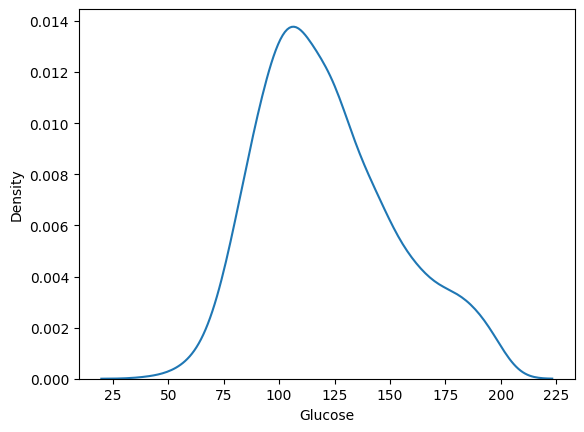

In [211]:
sns.kdeplot(df['Glucose'])

<Axes: xlabel='BloodPressure', ylabel='Density'>

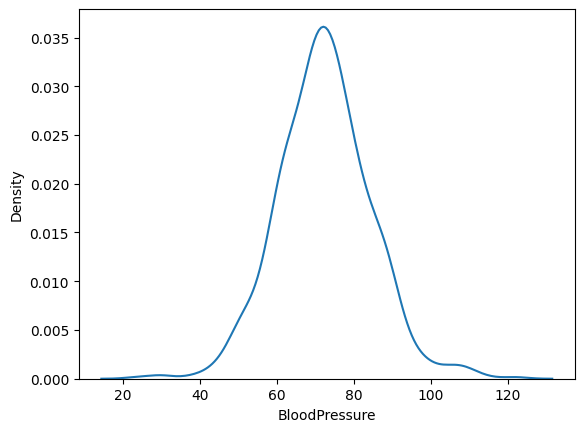

In [212]:
sns.kdeplot(df['BloodPressure'])

<Axes: xlabel='Insulin', ylabel='Density'>

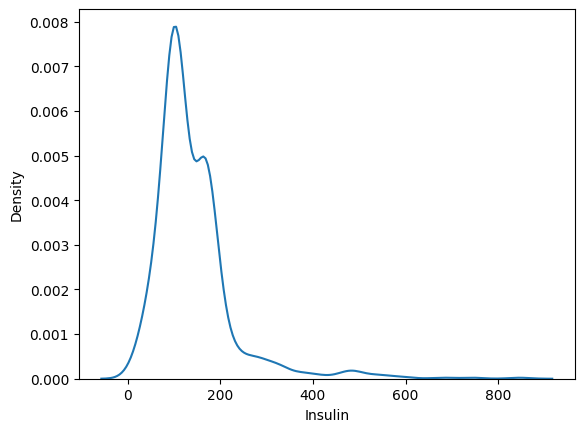

In [213]:
sns.kdeplot(df['Insulin'])

<Axes: xlabel='SkinThickness', ylabel='Density'>

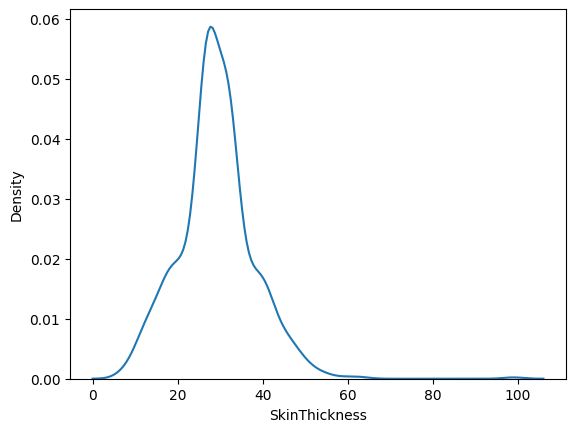

In [214]:
sns.kdeplot(df['SkinThickness'])

### Model

In [215]:
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

In [216]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [217]:
sc = StandardScaler()

In [218]:
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [219]:
model = Sequential()

In [220]:
model.add(Dense(32, input_dim=8, activation="relu",kernel_regularizer=tensorflow.keras.regularizers.l2(0.01),kernel_initializer="he_normal"))
model.add(BatchNormalization())
model.add(Dense(16, activation="relu",kernel_regularizer=tensorflow.keras.regularizers.l2(0.01),kernel_initializer="he_normal"))
model.add(BatchNormalization())
model.add(Dense(8, activation="relu",kernel_regularizer=tensorflow.keras.regularizers.l2(0.01),kernel_initializer="he_normal"))
model.add(BatchNormalization())
model.add(Dense(4, activation="relu",kernel_regularizer=tensorflow.keras.regularizers.l2(0.01),kernel_initializer="he_normal"))
model.add(BatchNormalization())
model.add(Dense(2, activation="relu",kernel_regularizer=tensorflow.keras.regularizers.l2(0.01),kernel_initializer="he_normal"))
model.add(BatchNormalization())
model.add(Dense(1, activation="sigmoid"))

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [221]:
callback = EarlyStopping(monitor="loss", patience=5 , verbose=1)

In [222]:
model.compile(optimizer="adam",loss="binary_crossentropy", metrics=["accuracy"],)

In [201]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=1000,                 # Set a high epoch count; early stopping will handle termination
    batch_size=768,
    callbacks=callback  # Pass inside the callbacks list
)

Epoch 1/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step - accuracy: 0.5098 - loss: 2.0197 - val_accuracy: 0.3312 - val_loss: 2.0395
Epoch 2/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 0.5212 - loss: 2.0044 - val_accuracy: 0.3117 - val_loss: 2.0270
Epoch 3/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - accuracy: 0.5244 - loss: 1.9888 - val_accuracy: 0.3182 - val_loss: 2.0149
Epoch 4/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - accuracy: 0.5326 - loss: 1.9735 - val_accuracy: 0.3312 - val_loss: 2.0032
Epoch 5/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - accuracy: 0.5326 - loss: 1.9585 - val_accuracy: 0.3247 - val_loss: 1.9920
Epoch 6/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 0.5407 - loss: 1.9440 - val_accuracy: 0.3182 - val_loss: 1.9810
Epoch 7/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - accuracy: 0.5505 - loss: 1.9299 - val_accuracy: 0.3312 - val_loss: 1.9705
Epoch 8/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - accuracy: 0.5586 - loss: 1.9161 - val_accuracy: 0.3312 - val

<Axes: >

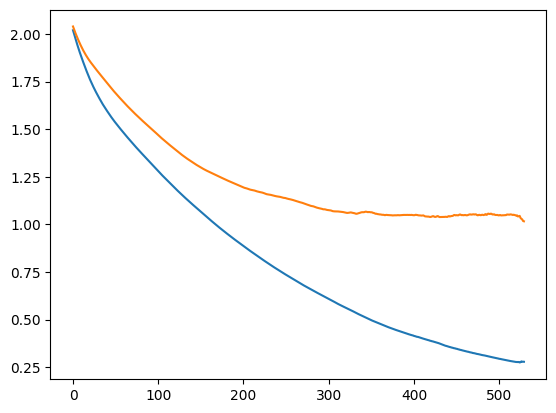

In [223]:
sns.lineplot(x=history.epoch, y=history.history["loss"])
sns.lineplot(x=history.epoch, y=history.history["val_loss"])

<Axes: >

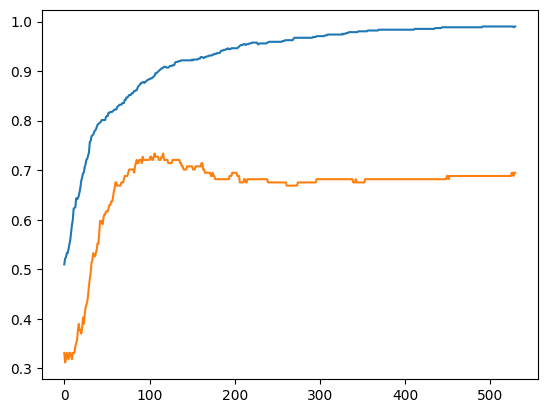

In [224]:
sns.lineplot(x=history.epoch, y=history.history["accuracy"])
sns.lineplot(x=history.epoch, y=history.history["val_accuracy"])

In [225]:
y_pred = model.predict(X_test)

1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


In [226]:
acc = accuracy_score(y_test, y_pred.round())
print("Accuracy:", acc)

Accuracy: 0.33116883116883117


### Normally training a model

In [227]:
model1 = Sequential()
model1.add(Dense(128, input_dim=8, activation="relu"))
model1.add(Dense(64, activation="relu"))
model1.add(Dense(32, activation="relu"))
model1.add(Dense(16, activation="relu"))
model1.add(Dense(1, activation="sigmoid"))
model1.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [228]:
history1 = model1.fit(X_train, y_train, epochs=200, batch_size=768, validation_data=(X_test, y_test))

Epoch 1/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.3502 - loss: 0.7200 - val_accuracy: 0.3831 - val_loss: 0.6935
Epoch 2/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step - accuracy: 0.4104 - loss: 0.6984 - val_accuracy: 0.5390 - val_loss: 0.6758
Epoch 3/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 296ms/step - accuracy: 0.5912 - loss: 0.6798 - val_accuracy: 0.6364 - val_loss: 0.6603
Epoch 4/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 313ms/step - accuracy: 0.6759 - loss: 0.6637 - val_accuracy: 0.7143 - val_loss: 0.6463
Epoch 5/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 259ms/step - accuracy: 0.7410 - loss: 0.6499 - val_accuracy: 0.7597 - val_loss: 0.6336
Epoch 6/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step - accuracy: 0.7541 - loss: 0.6377 - val_accuracy: 0.7727 - val_loss: 0.6221
Epoch 7/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step - accuracy: 0.7687 - loss: 0.6264 - val_accuracy: 0.7987 - val_loss: 0.6114
Epoch 8/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step - accuracy: 0.7801 - loss: 0.6154 - val_accuracy: 0.8052 - val_

<Axes: >

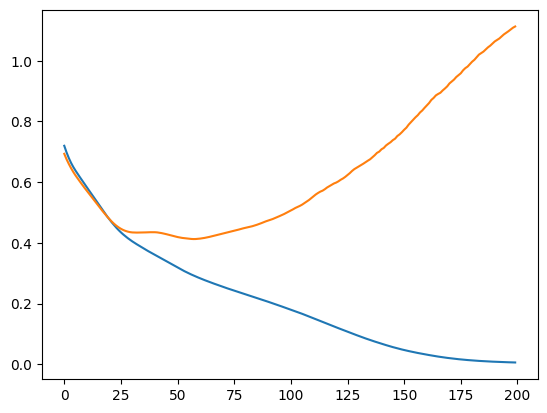

In [229]:
sns.lineplot(x=history1.epoch, y=history1.history["loss"])
sns.lineplot(x=history1.epoch, y=history1.history["val_loss"])

<Axes: >

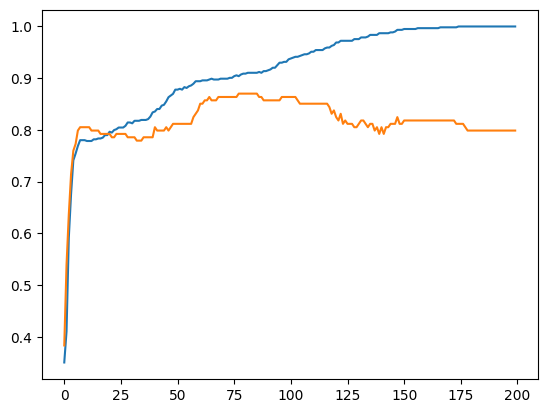

In [230]:
sns.lineplot(x=history1.epoch, y=history1.history["accuracy"])
sns.lineplot(x=history1.epoch, y=history1.history["val_accuracy"])

### Add normalization

In [231]:
model2 = Sequential()
model2.add(Dense(128, input_dim=8, activation="relu"))
model2.add(BatchNormalization())
model2.add(Dense(64, activation="relu"))
model2.add(BatchNormalization())
model2.add(Dense(32, activation="relu"))
model2.add(BatchNormalization())
model2.add(Dense(16, activation="relu"))
model2.add(Dense(1, activation="sigmoid"))
model2.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [232]:
model2.fit(X_train, y_train, epochs=200, batch_size=768, validation_data=(X_test, y_test))

Epoch 1/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step - accuracy: 0.6010 - loss: 0.6787 - val_accuracy: 0.7013 - val_loss: 0.6728
Epoch 2/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step - accuracy: 0.6971 - loss: 0.6167 - val_accuracy: 0.7273 - val_loss: 0.6673
Epoch 3/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 474ms/step - accuracy: 0.7378 - loss: 0.5696 - val_accuracy: 0.7208 - val_loss: 0.6619
Epoch 4/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 762ms/step - accuracy: 0.7638 - loss: 0.5337 - val_accuracy: 0.7403 - val_loss: 0.6567
Epoch 5/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 766ms/step - accuracy: 0.7834 - loss: 0.5051 - val_accuracy: 0.7597 - val_loss: 0.6518
Epoch 6/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - accuracy: 0.7997 - loss: 0.4814 - val_accuracy: 0.7532 - val_loss: 0.6472
Epoch 7/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step - accuracy: 0.8046 - loss: 0.4617 - val_accuracy: 0.7727 - val_loss: 0.6430
Epoch 8/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - accuracy: 0.8225 - loss: 0.4447 - val_accuracy: 0.7727 - val_l

### Dropout model

In [238]:
model3 = Sequential()
model3.add(Dense(128, input_dim=8, activation="relu"))
model3.add(Dropout(0.2))
model3.add(Dense(64, activation="relu"))
model3.add(Dropout(0.2))
model3.add(Dense(32, activation="relu"))
model3.add(Dropout(0.2))
model3.add(Dense(16, activation="relu"))
model3.add(Dense(1, activation="sigmoid"))
model3.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [239]:
history3 = model3.fit(X_train, y_train, epochs=1000, batch_size=32, validation_data=(X_test, y_test),callbacks=callback)

Epoch 1/1000
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.6417 - loss: 0.6374 - val_accuracy: 0.6558 - val_loss: 0.5732
Epoch 2/1000
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7248 - loss: 0.5297 - val_accuracy: 0.7792 - val_loss: 0.4724
Epoch 3/1000
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.7834 - loss: 0.4510 - val_accuracy: 0.7792 - val_loss: 0.4619
Epoch 4/1000
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8046 - loss: 0.4113 - val_accuracy: 0.7857 - val_loss: 0.4480
Epoch 5/1000
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8176 - loss: 0.4035 - val_accuracy: 0.8052 - val_loss: 0.4337
Epoch 6/1000
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8339 - loss: 0.3889 - val_accuracy: 0.8117 - val_loss: 0.4354
Epoch 7/1000
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8241 - loss: 0.3708 - val_accuracy: 0.8052 - val_loss: 0.4209
Epoch 8/1000
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8339 - loss: 0.3766 - val_accu

<Axes: >

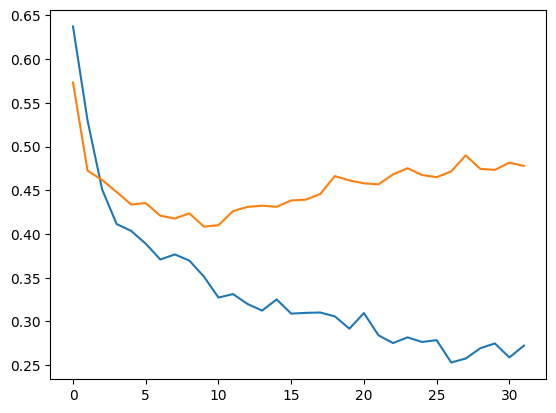

In [241]:
sns.lineplot(x=history3.epoch, y=history3.history["loss"])
sns.lineplot(x=history3.epoch, y=history3.history["val_loss"])

<Axes: >

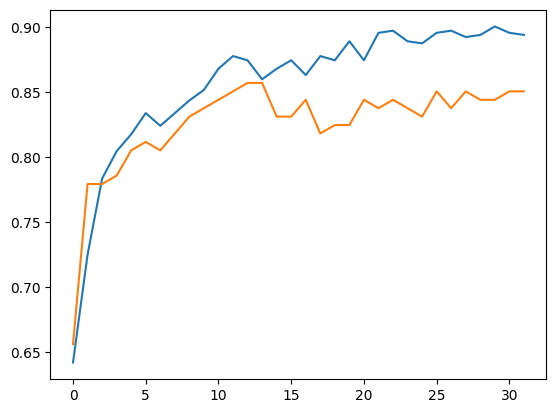

In [242]:
sns.lineplot(x=history3.epoch, y=history3.history["accuracy"])
sns.lineplot(x=history3.epoch, y=history3.history["val_accuracy"])

In [243]:
y_pred3 = model3.predict(X_test)
acc3 = accuracy_score(y_test, y_pred3.round())
print("Accuracy:", acc3)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
Accuracy: 0.8506493506493507


### Model with dropout and regularization

In [247]:
model4 = Sequential()
model4.add(Dense(128, input_dim=8, activation="relu",kernel_regularizer=tensorflow.keras.regularizers.l2(0.01),kernel_initializer="he_normal"))
model4.add(Dropout(0.2))
model4.add(Dense(64, activation="relu",kernel_regularizer=tensorflow.keras.regularizers.l2(0.01),kernel_initializer="he_normal"))
model4.add(Dropout(0.2))
model4.add(Dense(32, activation="relu",kernel_regularizer=tensorflow.keras.regularizers.l2(0.01),kernel_initializer="he_normal"))
model4.add(Dropout(0.2))
model4.add(Dense(16, activation="relu",kernel_regularizer=tensorflow.keras.regularizers.l2(0.01),kernel_initializer="he_normal"))
model4.add(Dense(1, activation="sigmoid"))
model4.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [251]:
history4 = model4.fit(X_train, y_train, epochs=200, batch_size=768, validation_data=(X_test, y_test))

Epoch 1/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 264ms/step - accuracy: 0.8648 - loss: 2.0947 - val_accuracy: 0.8312 - val_loss: 2.1749
Epoch 2/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step - accuracy: 0.8436 - loss: 2.0985 - val_accuracy: 0.8312 - val_loss: 2.1664
Epoch 3/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 186ms/step - accuracy: 0.8697 - loss: 2.0937 - val_accuracy: 0.8312 - val_loss: 2.1581
Epoch 4/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 201ms/step - accuracy: 0.8567 - loss: 2.0553 - val_accuracy: 0.8312 - val_loss: 2.1508
Epoch 5/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step - accuracy: 0.8550 - loss: 2.0837 - val_accuracy: 0.8312 - val_loss: 2.1434
Epoch 6/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 281ms/step - accuracy: 0.8502 - loss: 2.0597 - val_accuracy: 0.8312 - val_loss: 2.1366
Epoch 7/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 322ms/step - accuracy: 0.8616 - loss: 2.0672 - val_accuracy: 0.8247 - val_loss: 2.1296
Epoch 8/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step - accuracy: 0.8616 - loss: 2.0473 - val_accuracy: 0.8247 - v

<Axes: >

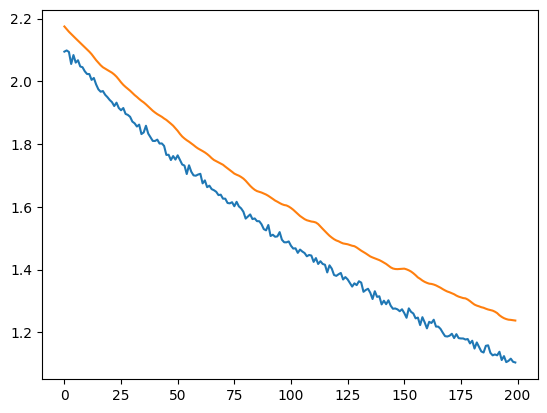

In [252]:
sns.lineplot(x=history4.epoch, y=history4.history["loss"])
sns.lineplot(x=history4.epoch, y=history4.history["val_loss"])

<Axes: >

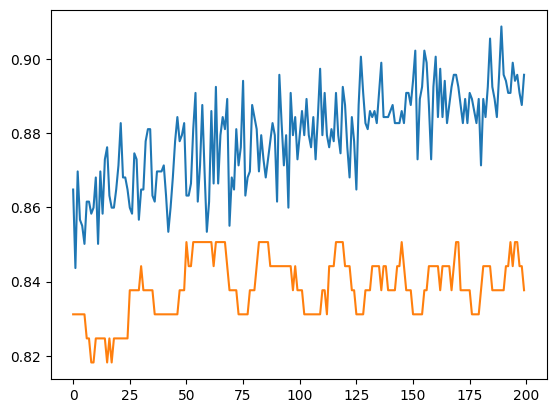

In [253]:
sns.lineplot(x=history4.epoch, y=history4.history["accuracy"])
sns.lineplot(x=history4.epoch, y=history4.history["val_accuracy"])

In [254]:
y_pred4 = model4.predict(X_test)
acc4 = accuracy_score(y_test, y_pred4.round())
print("Accuracy:", acc4)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
Accuracy: 0.8376623376623377
